<a href="https://colab.research.google.com/github/sakthivelselvarasu11/SMS_or_HAM-/blob/main/SMS_or_HAM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step by Step process
1. Importing Libraries
2. Data Visualization
3. Data Preprocessing
4. Model Training
5. Conclusion



In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/'): # Changed path to '/content/' to list all files
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/spam_ham_model.pkl
/content/vectorizer.pkl
/content/spam.csv
/content/.config/.last_update_check.json
/content/.config/config_sentinel
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/gce
/content/.config/default_configs.db
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations/config_default
/content/.config/logs/2025.11.17/14.29.23.259453.log
/content/.config/logs/2025.11.17/14.28.51.290851.log
/content/.config/logs/2025.11.17/14.29.22.058366.log
/content/.config/logs/2025.11.17/14.29.32.306715.log
/content/.config/logs/2025.11.17/14.29.13.881355.log
/content/.config/logs/2025.11.17/14.29.31.632779.log
/content/drive/MyDrive/Screenshot_20241005-003727 (1).png
/content/drive/MyDrive/PLACEMENT CH7 .gsheet
/content/drive/MyDrive/Untitled spreadsheet (18).gsheet
/content/drive/MyDrive/one c course.gsheet
/content/drive/MyDrive/Placement regi

## Importing Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


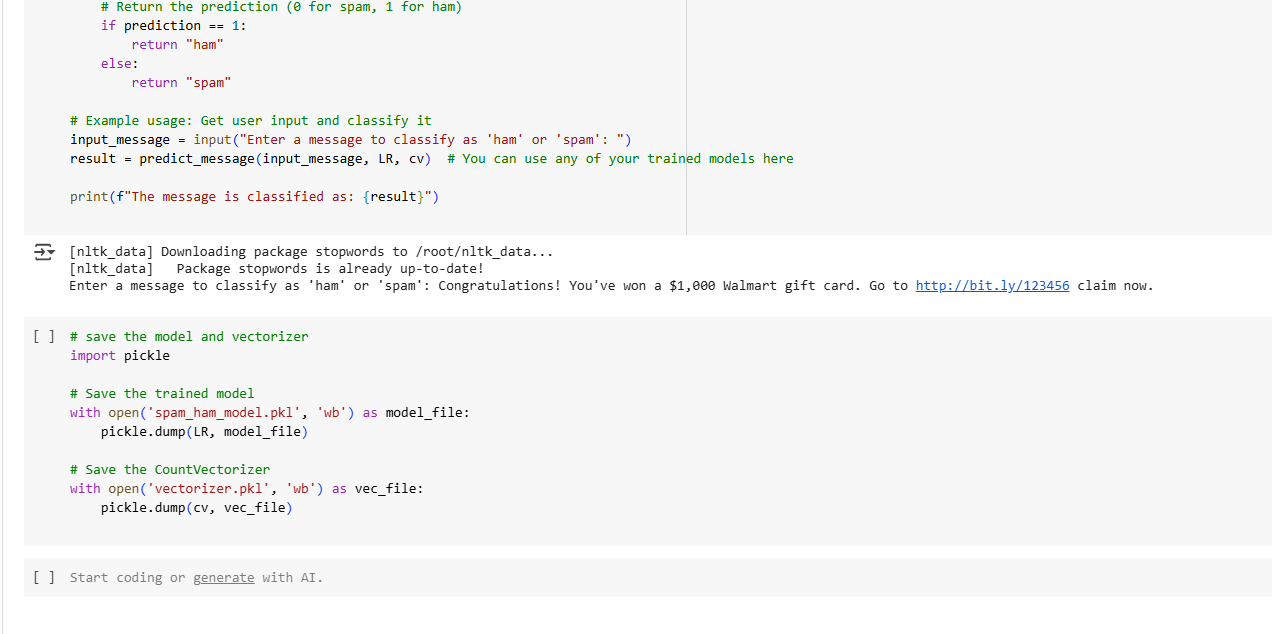## Dataset Reading

In [ ]:
df = pd.read_csv('/content/spam.csv',encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Null Values entry in Unnamed:2 column={}\nNull Values entry in Unnamed:3 column={}\nNull Values entry in Unnamed:4 column={}".format(df['Unnamed: 2'].isnull().sum(),df['Unnamed: 3'].isnull().sum(),df['Unnamed: 2'].isnull().sum()))

Null Values entry in Unnamed:2 column=5532
Null Values entry in Unnamed:3 column=5570
Null Values entry in Unnamed:4 column=5532


In [ ]:
print("shape of dataset: {}".format(df.shape))

shape of dataset: (5582, 5)


In [ ]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

In [ ]:
df.head(10)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [ ]:
df.rename(columns={'v1':'Label','v2':'Msg'},inplace=True)

## Data Visualization

total no. of ham msgs: 4830
total no. of spam msgs: 752


<Axes: xlabel='Label'>

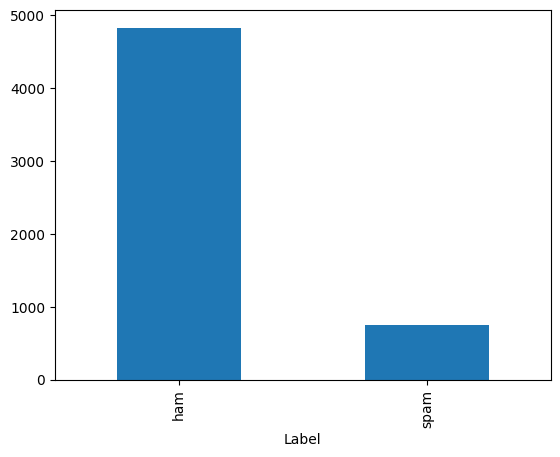

In [ ]:
print("total no. of ham msgs: {}\ntotal no. of spam msgs: {}".format(df['Label'].value_counts()[0],df['Label'].value_counts()[1]))
df['Label'].value_counts().plot.bar()

In [ ]:
df.describe()

,Label,Msg
count,5582,5582
unique,2,5179
top,ham,"Sorry, I'll call later"
freq,4830,30


In [ ]:
df['len'] = df['Msg'].apply(len)

In [ ]:
df.head()

,Label,Msg,len
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


## Let's see the longest msg and it label

In [ ]:
print("Message={}\n\nLabel={}".format(df['Msg'][df['len'].idxmax()],df['Label'][df['len'].idxmax()]))

Message=For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later..

Label=ham


##Let's see the shortest msg and its label

In [ ]:
print("Message={}\n\nLabel={}".format(df['Msg'][df['len'].idxmin()],df['Label'][df['len'].idxmin()]))

Message=Ok

Label=ham


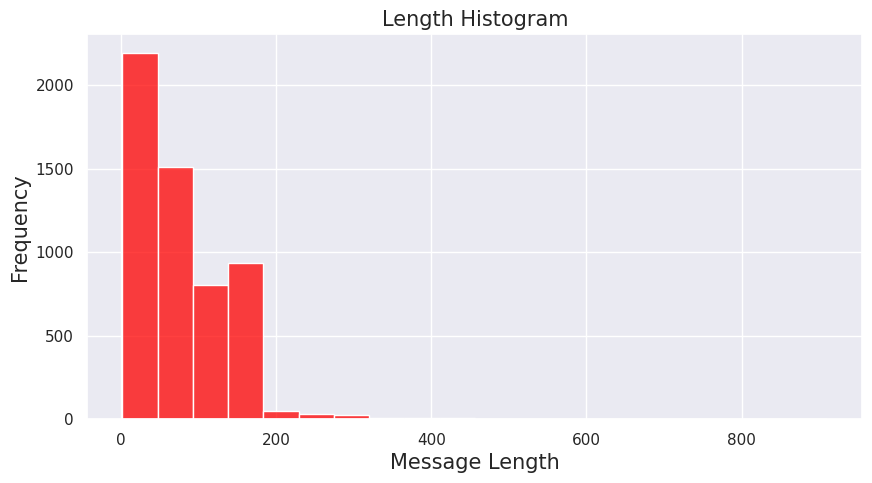

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')  # Use Seaborn style

plt.figure(figsize=(10,5))
sns.histplot(df['len'], kde=False, color='red', bins=20)  # histplot replaces distplot
plt.xlabel("Message Length", size=15)
plt.ylabel("Frequency", size=15)
plt.title("Length Histogram", size=15)
plt.show()



Text(0.5, 0, 'Message Length')

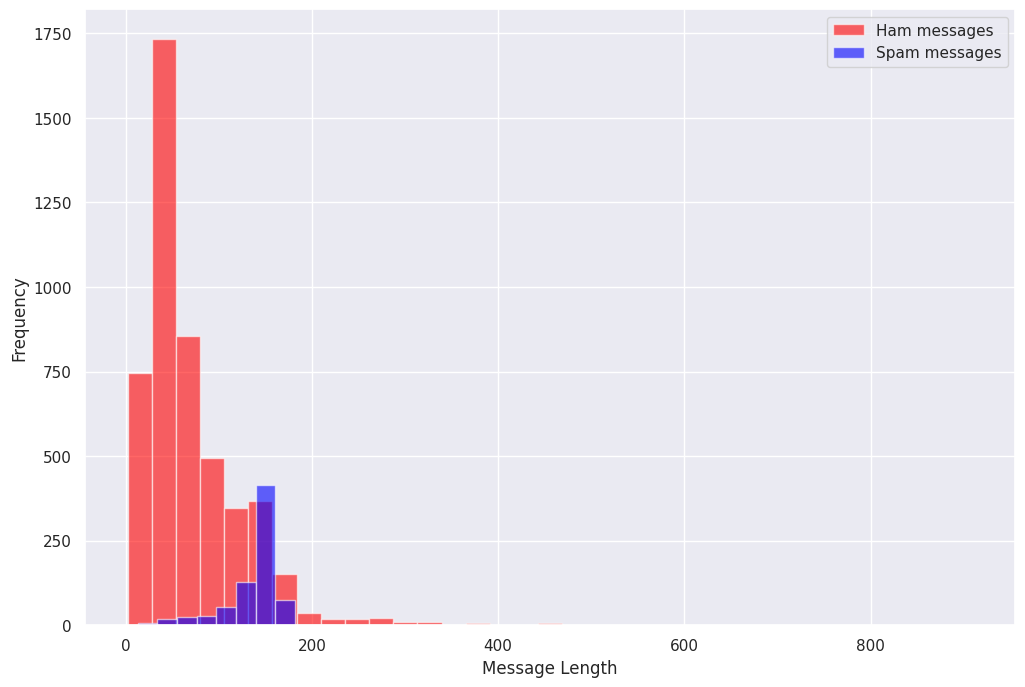

In [ ]:
plt.figure(figsize=(12, 8))

df[df['Label']=='ham'].len.plot(bins=35, kind='hist', color='red',
                                       label='Ham messages', alpha=0.6)
df[df['Label']=='spam'].len.plot(kind='hist', color='blue',
                                       label='Spam messages', alpha=0.6)
plt.legend()
plt.xlabel("Message Length")

##From this we can see that, spam label messages are of shorter length than ham messages

# DataPreProcessing

In [ ]:
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
ps = PorterStemmer() # Using porterstemmer for text preprocessing
message = []
for i in range(0, df.shape[0]):
    review = re.sub('[^a-zA-Z]', ' ', df['Msg'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    message.append(review)

In [ ]:
df['clean_msg']=np.empty((len(message),1))
for i in range(len(message)):
    df['clean_msg'][i]=message[i]
df['clean_msg_len']=df['clean_msg'].apply(len)
df.head()

,Label,Msg,len,clean_msg,clean_msg_len
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...,76
1,ham,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni,21
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri wkli comp win fa cup final tkt st m...,99
3,ham,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say,35
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though,36


In [ ]:
df['Msg'].describe()

,Msg
count,5582
unique,5179
top,"Sorry, I'll call later"
freq,30


In [ ]:
df['clean_msg'].describe()

,clean_msg
count,5582
unique,5066
top,sorri call later
freq,30


In [ ]:
df=pd.concat([df, pd.get_dummies(df['Label'])], axis=1)
df.drop(['Label'],axis=1,inplace=True)
df.drop(['spam'],axis=1,inplace=True)
df.rename(columns={'ham':'label'},inplace=True)
df.head()

,Msg,len,clean_msg,clean_msg_len,label
0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...,76,True
1,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni,21,True
2,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri wkli comp win fa cup final tkt st m...,99,False
3,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say,35,True
4,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though,36,True


##Vectorization

In [ ]:
X=df['clean_msg']
X

,clean_msg
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
2,free entri wkli comp win fa cup final tkt st m...
3,u dun say earli hor u c alreadi say
4,nah think goe usf live around though
...,...
5577,appl icloud id expir today log prevent delet h...
5578,netflix hello subscript expir renew month jjsm...
5579,well fargo bank account temporarili lock pleas...
5580,congratul walmart gift card go http bit ly claim


In [ ]:
Y=df['label']

##Using Countvectorizer for vectorization

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=2500)
X = cv.fit_transform(message).toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
# print(X)
Y=np.array(Y)
type(Y)
# t(Y)

numpy.ndarray

##Model Training

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.10, random_state = 0)

In [ ]:
print("X_train shape: {}\n X_test shape: {}\nY_train shape: {}\nY_test shape: {}".format(X_train.shape,X_test.shape,y_train.shape,y_test.shape))

X_train shape: (5023, 2500)
 X_test shape: (559, 2500)
Y_train shape: (5023,)
Y_test shape: (559,)


In [ ]:
# list for storing accuracy score of different algorithms
acc=[]

##Naive Bayes Classifier


In [ ]:
from sklearn import metrics
from sklearn.naive_bayes import MultinomialNB
spam_detect_model = MultinomialNB().fit(X_train, y_train)
pred=spam_detect_model.predict(X_test)

print("Accuracy of Naive Bayes Classifier is: {}".format(metrics.accuracy_score(y_test,pred)))
acc.append(metrics.accuracy_score(y_test,pred))

Accuracy of Naive Bayes Classifier is: 0.9821109123434705


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(solver='liblinear')
LR.fit(X_train,y_train)
yhat = LR.predict(X_test)
print("LogisticRegression's Accuracy:{0}".format(metrics.accuracy_score(y_test, yhat)))
acc.append(metrics.accuracy_score(y_test,yhat))

LogisticRegression's Accuracy:0.9821109123434705


##SVM

In [ ]:
from sklearn import svm
clf = svm.SVC(kernel='rbf')
clf.fit(X_train, y_train)
yhat = clf.predict(X_test)
print("SVM's Accuracy:{0}".format(metrics.accuracy_score(y_test, yhat)))
acc.append(metrics.accuracy_score(y_test, yhat))

SVM's Accuracy:0.9803220035778175


## Random Forest Classifiere

In [ ]:
from sklearn.ensemble import RandomForestClassifier
Random_forest = RandomForestClassifier(n_estimators=50)
Random_forest.fit(X_train,y_train)
randomForest_predict = Random_forest.predict(X_test)
randomForest_score = metrics.accuracy_score(y_test, randomForest_predict)
print("Random Forest Score :",randomForest_score)
acc.append(metrics.accuracy_score(y_test,randomForest_predict ))

Random Forest Score : 0.9821109123434705


##Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbk = GradientBoostingClassifier(random_state=100, n_estimators=150,min_samples_split=100, max_depth=6)
gbk.fit(X_train, y_train)
gbk_predict = gbk.predict(X_test)
print("Gradient Boosting Score :",metrics.accuracy_score(y_test,gbk_predict ))
acc.append(metrics.accuracy_score(y_test,gbk_predict ))

Gradient Boosting Score : 0.9821109123434705


## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
mx=-1
for i in range(1,25):

    neigh=KNeighborsClassifier(n_neighbors = i).fit(X_train,y_train)
    yhat = neigh.predict(X_test)
    KNN_score=metrics.accuracy_score(y_test, yhat)
    print("KNN Accuracy at {} is {}".format(i,KNN_score))
    mx=max(mx,KNN_score)
    print("\n")
acc.append(mx)
mx

KNN Accuracy at 1 is 0.9713774597495528


KNN Accuracy at 2 is 0.9713774597495528


KNN Accuracy at 3 is 0.9534883720930233


KNN Accuracy at 4 is 0.9570661896243292


KNN Accuracy at 5 is 0.9373881932021467


KNN Accuracy at 6 is 0.9373881932021467


KNN Accuracy at 7 is 0.9177101967799642


KNN Accuracy at 8 is 0.9177101967799642


KNN Accuracy at 9 is 0.9069767441860465


KNN Accuracy at 10 is 0.9069767441860465


KNN Accuracy at 11 is 0.9016100178890877


KNN Accuracy at 12 is 0.9016100178890877


KNN Accuracy at 13 is 0.8926654740608229


KNN Accuracy at 14 is 0.8926654740608229


KNN Accuracy at 15 is 0.8872987477638641


KNN Accuracy at 16 is 0.8872987477638641


KNN Accuracy at 17 is 0.8872987477638641


KNN Accuracy at 18 is 0.8872987477638641


KNN Accuracy at 19 is 0.8837209302325582


KNN Accuracy at 20 is 0.8837209302325582


KNN Accuracy at 21 is 0.8801431127012522


KNN Accuracy at 22 is 0.8801431127012522


KNN Accuracy at 23 is 0.8765652951699463


KNN Accuracy at 24 i

0.9713774597495528

Text(0, 0.5, 'Accuracy')

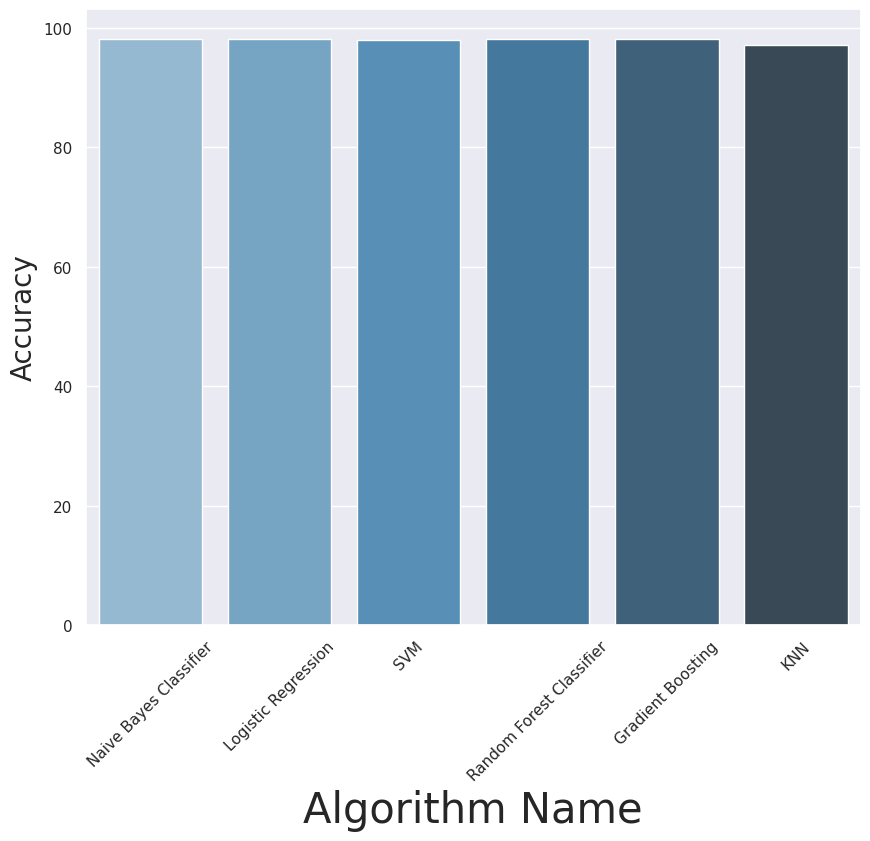

In [ ]:
algo_name=['Naive Bayes Classifier','Logistic Regression','SVM','Random Forest Classifier','Gradient Boosting','KNN']
acc=np.array(acc)
from numpy import median
plt.figure(figsize=(10,8))
sns.barplot(y=acc*100,x=algo_name,estimator=median,palette="Blues_d")
plt.xlabel('Algorithm Name',size=30)
plt.xticks(rotation=45)
plt.ylabel('Accuracy',size=20)

In [ ]:
# Assuming you have the following variables already trained:
# spam_detect_model (Naive Bayes model)
# LR (Logistic Regression model)
# cv (CountVectorizer)
# df (your dataset)

# Function to preprocess user input (same as your data preprocessing)
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

# Load stopwords and initialize stemmer
nltk.download('stopwords')
ps = PorterStemmer()

def preprocess_message(msg):
    # Remove any non-alphabetic characters
    review = re.sub('[^a-zA-Z]', ' ', msg)
    # Convert to lowercase
    review = review.lower()
    # Tokenize and remove stopwords, then apply stemming
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    # Join the processed words back together
    review = ' '.join(review)
    return review

# Function to predict whether a message is "ham" or "spam"
def predict_message(msg, model, vectorizer):
    # Preprocess the input message
    msg = preprocess_message(msg)



    # Vectorize the input message using the same vectorizer
    msg_vectorized = vectorizer.transform([msg]).toarray()

    # Predict the label (ham or spam)
    prediction = model.predict(msg_vectorized)

    # Return the prediction (0 for spam, 1 for ham)
    if prediction == 1:
        return "ham"
    else:
        return "spam"

# Example usage: Get user input and classify it
input_message = input("Enter a message to classify as 'ham' or 'spam': ")
result = predict_message(input_message, LR, cv)  # You can use any of your trained models here

print(f"The message is classified as: {result}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# save the model and vectorizer
import pickle

# Save the trained model
with open('spam_ham_model.pkl', 'wb') as model_file:
    pickle.dump(LR, model_file)

# Save the CountVectorizer
with open('vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(cv, vec_file)


In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok colabcode scikit-learn nltk

Requested uvicorn from https://files.pythonhosted.org/packages/ef/67/546c35e9fffb585ea0608ba3bdcafe17ae402e304367203d0b08d6c23051/uvicorn-0.13.1-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Please use pip<24.1 if you need to use this version.
INFO: pip is looking at multiple versions of colabcode to determine which version is compatible with other requirements. This could take a while.
  Using cached uvicorn-0.13.1-py3-none-any.whl.metadata (4.6 kB)
Requested uvicorn from https://files.pythonhosted.org/packages/ef/67/546c35e9fffb585ea0608ba3bdcafe17ae402e304367203d0b08d6c23051/uvicorn-0.13.1-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Please use pip<24.1 if you need to use this version.
  Using cached uvicorn-0.13.1-py3-none-any.whl.

In [ ]:
from pyngrok import conf, ngrok

conf.get_default().auth_token = "35SB9tfdEbg22mFJ4IDQVRxLazY_5S4aSM6noZdHRrLKTPAR2"

In [ ]:
!rm -rf ~/.ngrok2

In [ ]:
import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from pyngrok import ngrok
import uvicorn
import pickle
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

# Download stopwords if missing
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

ps = PorterStemmer()
app = FastAPI()

# CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

class TextInput(BaseModel):
    message: str

class PredictionResponse(BaseModel):
    message: str
    prediction: str
    confidence: str

def preprocess_message(msg):
    review = re.sub('[^a-zA-Z]', ' ', msg).lower().split()
    stop_words = set(stopwords.words('english'))
    review = [ps.stem(word) for word in review if word not in stop_words]
    return ' '.join(review)

# Load model + vectorizer
with open("spam_ham_model.pkl", "rb") as f:
    spam_ham_model = pickle.load(f)

with open("vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

@app.get("/")
def root():
    return {"status": "running"}

@app.post("/predict_spam_or_ham", response_model=PredictionResponse)
def predict_msg(input_text: TextInput):
    pre = preprocess_message(input_text.message)
    vec = vectorizer.transform([pre]).toarray()
    pred = spam_ham_model.predict(vec)[0]
    prob = max(spam_ham_model.predict_proba(vec)[0])
    result = "ham" if pred == 1 else "spam"
    return PredictionResponse(
        message=input_text.message,
        prediction=result,
        confidence=f"{prob:.2%}"
    )

if __name__ == "__main__":
    ngrok.set_auth_token("35SB9tfdEbg22mFJ4IDQVRxLazY_5S4aSM6noZdHRrLKTPAR2")

    # Kill any existing ngrok tunnels before starting a new one
    ngrok.kill()

    # Start ngrok tunnel
    public_url = ngrok.connect(8000)
    print("Public URL:", public_url)
    print("Swagger:", f"{public_url}/docs")

    # Start Uvicorn inside Jupyter
    from uvicorn import Config, Server
    import nest_asyncio
    nest_asyncio.apply()

    config = Config(app=app, host="0.0.0.0", port=8000, log_level="info")
    server = Server(config)

    await server.serve()

Public URL: NgrokTunnel: "https://hypsographical-luke-heathlike.ngrok-free.dev" -> "http://localhost:8000"
Swagger: NgrokTunnel: "https://hypsographical-luke-heathlike.ngrok-free.dev" -> "http://localhost:8000"/docs


INFO:     Started server process [311]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2402:3a80:195c:a4d::2:0 - "POST / HTTP/1.1" 405 Method Not Allowed


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [311]
